# Assignment 2 group 3

## 1. Face image classification with Support Vector Machines

The assignment is related to the face recognition problem: train a SVM to recognize the face of a given person.

1. Load from Sklearn the Olivetti faces dataset with `faces = fetch_olivetti_faces()`. `faces.DESCR` will give you a description of the dataset.
2. Understand the data format: the data are in `faces.images`, the relative labels in `faces.target`. Print the number of images, the number of unique labels, the skew of each label, the number of features.
3. Implement a function to plot an image in the dataset given an identifier number.
4. Split the dataset into train and test and train a SVM by using a k-fold cross validation on the training set.
5. Optimize the hyperparameters C, the type of kernel (choose between `linear`, `poly` and `rbf`) and gamma. What is the difference in performance by using the optimized parameters vs the default parameters of Sklearn for a SVM?
6. Train the SVM with the best param configuration on the whole training set and compute the f1 and the confusion matrix on the test set.
5. Give your own comments and analysis on points 5 and 6.


## 2. Clustering of Face Images

1. perform Kmeans with several values for K (that is the number of clusters) on the above dataset;
2. use the Elbow method for choosing a right number for K and perform the clustering;
3. show the centroids of each clustering with `subplot` and `imshow`. The centroids are flatten arrays, you have to reshape in image format: 64x64 pixels;
4. as the face dataset provides the true labels in `faces.target` compute the accuracy and the confusion matrix (search the relative sklearn functions):
    - the cluster labels computed by kmeans are just artificial labels that do not share anything with the true labels. You have to infer the true labels from the clusters by using the true labels in `faces.target`. You can use a voting criterion: the predicted cluster label will be the one with more instances in the cluster. For example, if a cluster contains images corresponding to these faces [1,2,3,1,1,1], then the cluster label will be with 1.
5. Give your own comments and analysis on points 2, 3 and 4.

1.1. Load from Sklearn the Olivetti faces dataset with `faces = fetch_olivetti_faces()`. `faces.DESCR` will give you a description of the dataset.

In [38]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np


faces = fetch_olivetti_faces()



2. Understand the data format: the data are in `faces.images`, the relative labels in `faces.target`. Print the number of images, the number of unique labels, the skew of each label, the number of features.

In [39]:
num_images = faces.images.shape[0]
num_unique_labels = np.unique(faces.target).size
label_counts = np.bincount(faces.target)
skew_per_label = label_counts
num_features = faces.data.shape[1]

print(f"Number of images: {num_images}")
print(f"Number of unique labels: {num_unique_labels}")
print(f"Number of features: {num_features}")
print("Skew (number of images per label):")
for label, count in enumerate(skew_per_label):
    print(f"Person {label}: {count}")



Number of images: 400
Number of unique labels: 40
Number of features: 4096
Skew (number of images per label):
Person 0: 10
Person 1: 10
Person 2: 10
Person 3: 10
Person 4: 10
Person 5: 10
Person 6: 10
Person 7: 10
Person 8: 10
Person 9: 10
Person 10: 10
Person 11: 10
Person 12: 10
Person 13: 10
Person 14: 10
Person 15: 10
Person 16: 10
Person 17: 10
Person 18: 10
Person 19: 10
Person 20: 10
Person 21: 10
Person 22: 10
Person 23: 10
Person 24: 10
Person 25: 10
Person 26: 10
Person 27: 10
Person 28: 10
Person 29: 10
Person 30: 10
Person 31: 10
Person 32: 10
Person 33: 10
Person 34: 10
Person 35: 10
Person 36: 10
Person 37: 10
Person 38: 10
Person 39: 10


3. Implement a function to plot an image in the dataset given an identifier number.

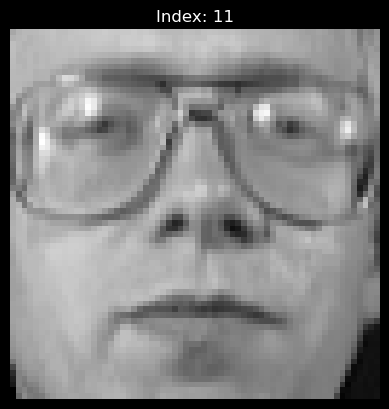

In [40]:

import matplotlib.pyplot as plt

def plot_img(index: int):
    plt.imshow(faces.images[index], cmap='gray')
    plt.title(f"Index: {index}")
    plt.axis('off')
    plt.show()

plot_img(11)


4. Split the dataset into train and test and train a SVM by using a k-fold cross validation on the training set.

In [41]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC

# Split the dataset into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    faces.data, faces.target, test_size=0.2, random_state=42, stratify=faces.target
)

# Set up k-fold cross-validation (k=5)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train a SVM with default parameters using cross-validation on the training set
svm = SVC()
cv_scores = cross_val_score(svm, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")

Cross-validation accuracy scores: [0.90625  0.921875 0.859375 0.953125 0.875   ]
Mean cross-validation accuracy: 0.9031


In [42]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

# Set up GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=kfold, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Default SVM mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Improvement: {grid_search.best_score_ - cv_scores.mean():.4f}")

Best parameters found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.9625
Default SVM mean CV accuracy: 0.9031
Improvement: 0.0594


6. Train the SVM with the best param configuration on the whole training set and compute the f1 and the confusion matrix on the test set.

In [43]:
from sklearn.metrics import f1_score, confusion_matrix

# Train SVM with the best parameters on the whole training set
best_svm = SVC(**grid_search.best_params_)
best_svm.fit(X_train, y_train)

# Predict on the test set
y_pred = best_svm.predict(X_test)

# Compute the F1 score (macro for multiclass)
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print(f"F1 score (macro): {f1:.4f}")
print("Confusion matrix:")
print(cm)

F1 score (macro): 0.9733
Confusion matrix:
[[2 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 0 2]]


Give your own comments and analysis on points 5 and 6.

## 2.

1. perform Kmeans with several values for K (that is the number of clusters) on the above dataset;
2. use the Elbow method for choosing a right number for K and perform the clustering;


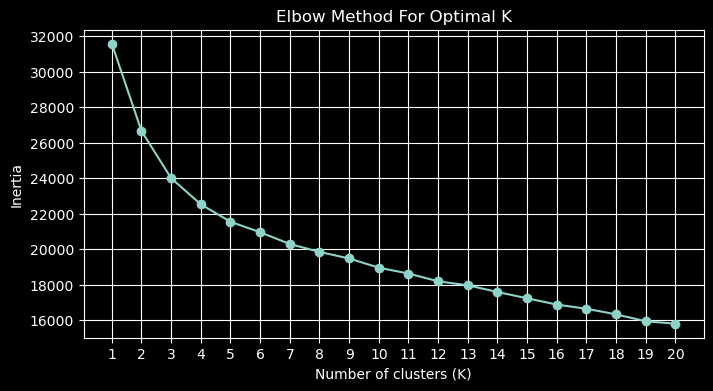

the right number is ~ 3/4


In [44]:
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

# Try different values for K and compute inertia (sum of squared distances to closest cluster center)
inertia = []
K_range = range(1, 21)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(faces.data)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

print('the right number is ~ 3/4')

3. show the centroids of each clustering with `subplot` and `imshow`. The centroids are flatten arrays, you have to reshape in image format: 64x64 pixels;

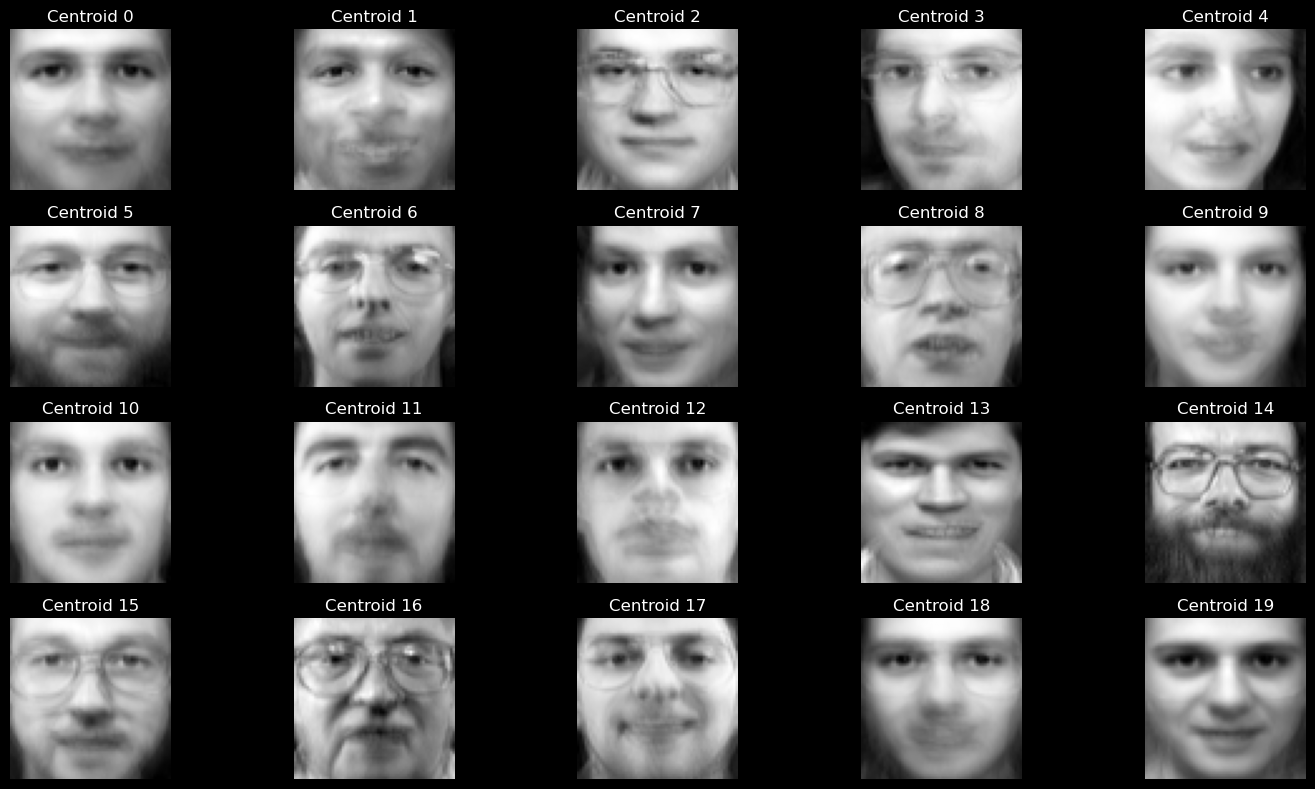

In [48]:
# Show the centroids of each clustering with subplot and imshow
kmeans = KMeans(n_clusters=20, random_state=42)
kmeans.fit(faces.data)
n_clusters = kmeans.n_clusters
centroids = kmeans.cluster_centers_

plt.figure(figsize=(15, 8))
for i in range(n_clusters):
    plt.subplot(4, 5, i + 1)
    plt.imshow(centroids[i].reshape(64, 64), cmap='gray')
    plt.title(f'Centroid {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

. as the face dataset provides the true labels in `faces.target` compute the accuracy and the confusion matrix (search the relative sklearn functions):
- the cluster labels computed by kmeans are just artificial labels that do not share anything with the true labels. You have to infer the true labels from the clusters by using the true labels in `faces.target`. You can use a voting criterion: the predicted cluster label will be the one with more instances in the cluster. For example, if a cluster contains images corresponding to these faces [1,2,3,1,1,1], then the cluster label will be with 1.

In [46]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Assign each cluster to the most frequent true label in that cluster
labels_true = faces.target
labels_pred = kmeans.labels_

# Map each cluster to the most common true label
label_map = {}
for cluster in range(n_clusters):
    mask = labels_pred == cluster
    if np.any(mask):
        label_map[cluster] = mode(labels_true[mask], keepdims=True)[0][0]
    else:
        label_map[cluster] = -1  # In case a cluster is empty

# Predict labels using the mapping
predicted_labels = np.array([label_map[cluster] for cluster in labels_pred])

# Compute accuracy and confusion matrix
acc = accuracy_score(labels_true, predicted_labels)
cm_kmeans = confusion_matrix(labels_true, predicted_labels)

print(f"KMeans clustering accuracy (after voting): {acc:.4f}")
print("Confusion matrix (KMeans):")
cm_kmeans
cm_kmeans_df = pd.DataFrame(cm_kmeans)
cm_kmeans_df

KMeans clustering accuracy (after voting): 0.3950
Confusion matrix (KMeans):


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,2,0,0
1,0,10,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,7,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,7,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,0,0,0,4,0,0
8,0,0,0,0,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,5,0,0


5. Give your own comments and analysis on points 2, 3 and 4.



exp 2: ...
exp 3: it is kind of strange to see the centroid of a face
exp 4: unsupervised learning has a low accuracy (~0.4) compared to supervised learning, but is still far better then random